# Regresión lineal simple


A lo largo de los siguientes ejercicios, aprenderás a usar Python para construir un modelo de regresión lineal simple. Antes de comenzar con este ejercicio de programación, te recomendamos encarecidamente ver la conferencia en video y completar la IVQ para los temas asociados.


Toda la información que necesitas para resolver esta tarea está en este cuaderno, y todo el código que implementarás tendrá lugar dentro de este cuaderno.


A medida que avanzamos, puedes encontrar instrucciones sobre cómo instalar las bibliotecas requeridas a medida que surjan en este cuaderno. Antes de comenzar con los ejercicios y analizar los datos, necesitamos importar todas las bibliotecas y extensiones requeridas para este ejercicio de programación. A lo largo del curso, utilizaremos pandas y statsmodels para operaciones, y seaborn para gráficos.


## Importaciones relevantes


Comienza importando los paquetes y datos relevantes.


In [1]:
# Import packages
import pandas as pd
import seaborn as sns

**Nota:** Recuerda que el valor predeterminado de `head()` es mostrar las primeras 5 filas. Si cambias el valor de `n`, puedes mostrar más filas. Por ejemplo, si cargas el conjunto de datos sns y lo llamas "penguins," el comando `penguins.head(3)` mostrará 3 filas.


In [ ]:
# carg dataset
penguins = sns.load_dataset("penguins")

# Ecaminamos los primeros registros
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


Desde las primeras 5 filas del conjunto de datos, podemos ver que hay varias columnas disponibles: `species`, `island`, `bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`, `body_mass_g`, y `sex`. También parece haber algunos datos faltantes.


In [3]:
penguins.columns

Index(['species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex'],
      dtype='str')

In [4]:
penguins.shape

(344, 7)

## Limpieza de datos (no mostrada en videos)


Para los propósitos de este curso, estamos enfocando nuestro análisis en pingüinos Adelie y Gentoo, y eliminaremos cualquier valor faltante del conjunto de datos. En un entorno de trabajo, normalmente examinarías los datos más a fondo antes de decidir cómo manejar los datos faltantes (es decir, rellenar, eliminar, etc.). Por favor, consulta nuevamente el contenido del programa anterior si necesitas revisar cómo manejar los datos faltantes.


In [12]:
# Keep Adelie and Gentoo penguins, drop missing values
penguins_sub = penguins[penguins["species"] != "Chinstrap"]
penguins_final = penguins_sub.dropna()
penguins_final.reset_index(inplace=True, drop=True)

In [13]:
display(penguins_final.head())
print(f"Cantidad de fileas eliminadas: {penguins.shape[0] - penguins_final.shape[0]}")
print(f"Cantidad de Columnas insertadas: {penguins_final.shape[1] - penguins.shape[1]}")

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


Cantidad de fileas eliminadas: 79
Cantidad de Columnas insertadas: 0


Puedes revisar la documentación para [`dropna()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.dropna.html) y [`reset_index()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.reset_index.html). En resumen, la función `dropna()` por defecto elimina cualquier fila con cualquier valor faltante en cualquiera de las columnas. La función `reset_index()` restablece los valores del índice para las filas en el DataFrame. Normalmente, usas `reset_index()` después de haber terminado de manipular el conjunto de datos. Al establecer `inplace=True`, no crearás un nuevo objeto DataFrame. Al establecer `drop=True`, no insertarás una nueva columna de índice en el objeto DataFrame.


## Análisis exploratorio de datos


Antes de construir cualquier modelo, es importante familiarizarse más con sus datos. Puede hacerlo realizando análisis exploratorio de datos o EDA. Por favor, revise los materiales del programa anteriores según sea necesario si desea volver a familiarizarse con los conceptos de EDA.

Dado que esta parte del curso se centra en la regresión lineal simple, desea verificar si hay alguna relación lineal entre las variables en el marco de datos. Puede hacer esto creando diagramas de dispersión usando cualquier paquete de visualización de datos, por ejemplo `matplotlib.plt`, `seaborn`, o `plotly`.

Para visualizar más de una relación al mismo tiempo, usamos la función `pairplot()` del paquete `seaborn` para crear una matriz de diagramas de dispersión.


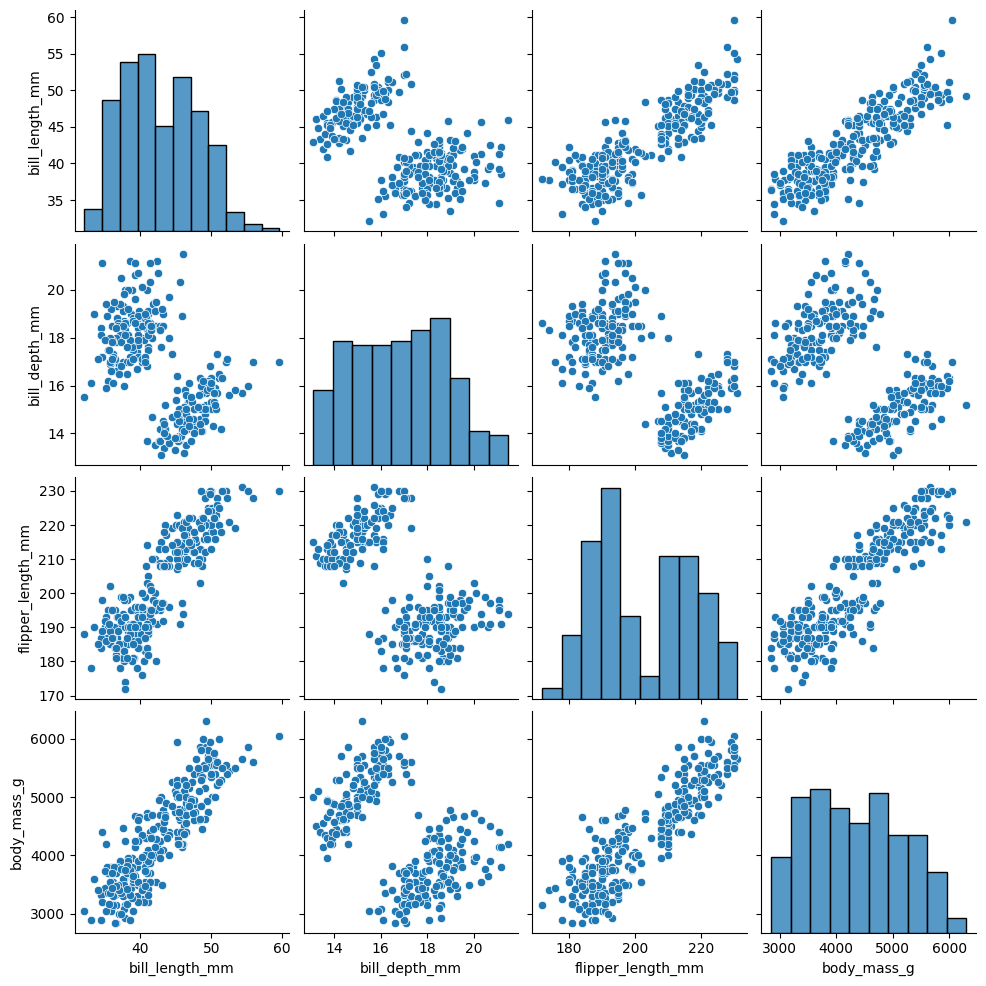

In [14]:
# Create pairwise scatterplots of data set
sns.pairplot(penguins_final)

Desde la matriz de diagramas de dispersión, puedes observar algunas relaciones lineales:
* longitud del pico (mm) y longitud de la aleta (mm)
* longitud del pico (mm) y masa corporal (g)
* longitud de la aleta (mm) y masa corporal (g)


## Construcción del modelo


Basado en los diagramas de dispersión anteriores, probablemente podrías realizar una regresión lineal simple en cualquiera de las tres relaciones identificadas. Para esta parte del curso, te enfocarás en la relación entre la longitud del pico (mm) y la masa corporal (g).

Para hacer esto, primero seleccionarás las variables de interés del dataframe. Puedes hacer esto usando doble corchete `[[]]`, y listando los nombres de las columnas de interés.


In [15]:
# Subset Data
ols_data = penguins_final[["bill_length_mm", "body_mass_g"]]
display(ols_data.head())

,bill_length_mm,body_mass_g
0,39.1,3750.0
1,39.5,3800.0
2,40.3,3250.0
3,36.7,3450.0
4,39.3,3650.0


A continuación, puedes construir la fórmula de regresión lineal y guardarla como una cadena. Recuerda que la variable y o dependiente va antes del `~`, y las variables x o independientes van después del `~`.

**Nota:** Los nombres de las variables x e y deben coincidir exactamente con los nombres de las columnas en el dataframe.


In [16]:
# Write out formula
ols_formula = "body_mass_g ~ bill_length_mm"
print(ols_formula)

body_mass_g ~ bill_length_mm


Por último, puedes construir el modelo de regresión lineal simple en `statsmodels` usando la función `ols()`. Puedes importar la función `ols()` directamente usando la línea de código a continuación.


In [17]:
# Import ols function
from statsmodels.formula.api import ols

Luego, puedes ingresar la `ols_formula` y `ols_data` como argumentos en la función `ols()`. Después de guardar los resultados como una variable, puedes llamar a la función `fit()` para ajustar realmente el modelo a los datos.


In [18]:
# Build OLS, fit model to data
OLS = ols(formula = ols_formula, data = ols_data)
model = OLS.fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            body_mass_g   R-squared:                       0.769
Model:                            OLS   Adj. R-squared:                  0.768
Method:                 Least Squares   F-statistic:                     874.3
Date:                Fri, 13 Feb 2026   Prob (F-statistic):           1.33e-85
Time:                        14:19:32   Log-Likelihood:                -1965.8
No. Observations:                 265   AIC:                             3936.
Df Residuals:                     263   BIC:                             3943.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept      -1707.2919    205.640     -8.

Por último, puedes llamar a la función `summary()` en el objeto `model` para obtener los coeficientes y más estadísticas sobre el modelo. La salida de `model.summary()` puede ser utilizada para evaluar el modelo e interpretar los resultados. Más adelante en esta sección, revisaremos cómo leer los resultados de la salida del modelo.


In [19]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            body_mass_g   R-squared:                       0.769
Model:                            OLS   Adj. R-squared:                  0.768
Method:                 Least Squares   F-statistic:                     874.3
Date:                Fri, 13 Feb 2026   Prob (F-statistic):           1.33e-85
Time:                        14:20:10   Log-Likelihood:                -1965.8
No. Observations:                 265   AIC:                             3936.
Df Residuals:                     263   BIC:                             3943.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept      -1707.2919    205.640     -8.302      0.000   -2112.202   -1302.382
bill_length_mm   141.1904      4.775     29.569      0.000     131.788     150.592
==============================================================================
Omnibus:                        2.060   Durbin-Watson:                   2.067
Prob(Omnibus):                  0.357   Jarque-Bera (JB):                2.103
Skew:                           0.210   Prob(JB):                        0.349
Kurtosis:                       2.882   Cond. No.                         357.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Puedes usar la función `regplot()` de `seaborn` para visualizar la línea de regresión.


<Axes: xlabel='bill_length_mm', ylabel='body_mass_g'>

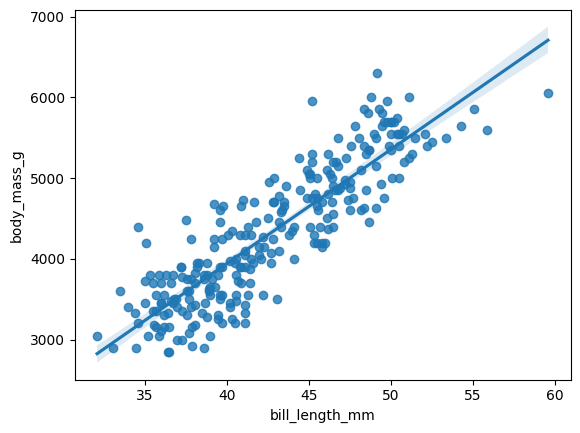

In [20]:
sns.regplot(x = "bill_length_mm", y = "body_mass_g", data = ols_data)

## Terminar de verificar las suposiciones del modelo


Como aprendiste en videos anteriores, hay cuatro supuestos principales del modelo para la regresión lineal simple, en ningún orden en particular:
1. Linealidad
2. Normalidad
3. Observaciones independientes
4. Homocedasticidad

Ya verificaste el supuesto de linealidad creando la matriz de diagramas de dispersión. El supuesto de observaciones independientes tiene más que ver con la recopilación de datos. No hay razón para creer que la masa corporal de un pingüino o la longitud del pico estén relacionadas con las mediciones anatómicas de otro pingüino. Entonces podemos marcar los supuestos 1 y 3.

Los supuestos de normalidad y homocedasticidad se centran en la distribución de los errores. Por lo tanto, solo puedes verificar estos supuestos después de haber construido el modelo. Para verificar estos supuestos, revisarás los residuos, como una aproximación de los errores.

Para verificar más fácilmente los supuestos del modelo y crear visualizaciones relevantes, primero puedes segmentar la variable X aislando solo la columna `bill_length_mm`. Además, puedes guardar los valores predichos del modelo usando la función `model.predict(X)`.


In [21]:
# Subset X variable
X = ols_data["bill_length_mm"]

# Get predictions from model
fitted_values = model.predict(X)

Luego, puedes guardar los residuos del modelo como una variable usando el atributo `model.resid`.


In [22]:
# Calculate residuals
residuals = model.resid

### Verifique la suposición de normalidad


Para verificar la suposición de normalidad, puedes crear un histograma de los residuos usando la función `histplot()` del paquete `seaborn`.

Desde el histograma a continuación, puedes notar que los residuos están casi distribuidos normalmente. En este caso, es probable que esté lo suficientemente cerca de que la suposición se cumpla.


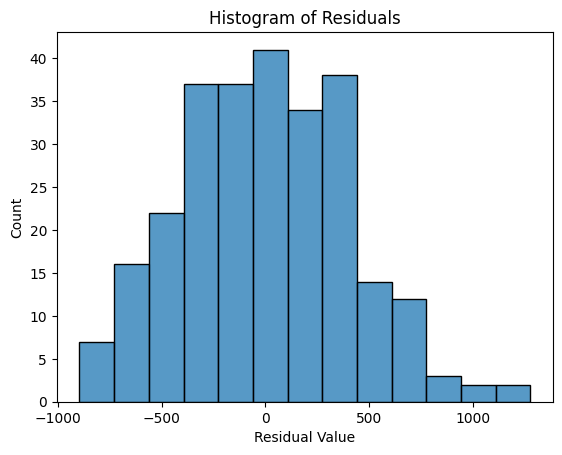

In [23]:
import matplotlib.pyplot as plt
fig = sns.histplot(residuals)
fig.set_xlabel("Residual Value")
fig.set_title("Histogram of Residuals")
plt.show()

Otra forma de verificar la función de normalidad es crear un gráfico cuantil-cuantil o gráfico Q-Q. Recuerda que si los residuos están distribuidos normalmente, esperarías una línea diagonal recta que vaya desde la esquina inferior izquierda hasta la esquina superior derecha del gráfico Q-Q. Puedes crear un gráfico Q-Q usando la función `qqplot` del paquete `statsmodels.api`.

El gráfico Q-Q muestra un patrón similar al histograma, donde los residuos están mayormente distribuidos normalmente, excepto en los extremos de la distribución.


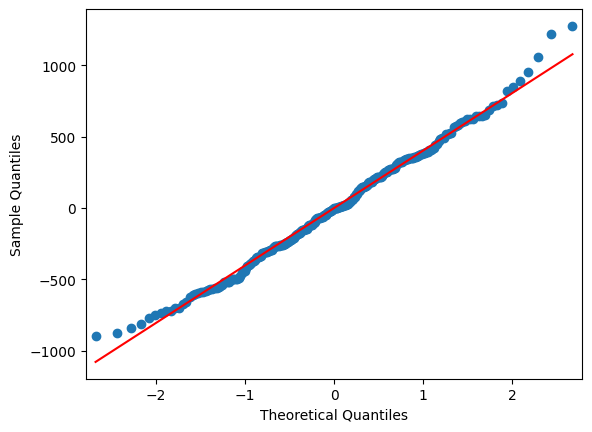

In [24]:
import matplotlib.pyplot as plt
import statsmodels.api as sm
fig = sm.qqplot(model.resid, line = 's')
plt.show()

### Verifique la suposición de homocedasticidad


Por último, tenemos que verificar la suposición de homocedasticidad. Para verificar la suposición de homocedasticidad, puedes crear un diagrama de dispersión de los valores ajustados y los residuos. Si el gráfico se asemeja a una nube aleatoria (es decir, los residuos están dispersos aleatoriamente), entonces la suposición probablemente se cumple.

Puedes crear un diagrama de dispersión usando la función `scatterplot()` del paquete `seaborn`. El primer argumento es la variable que va en el eje x. El segundo argumento es la variable que va en el eje y.


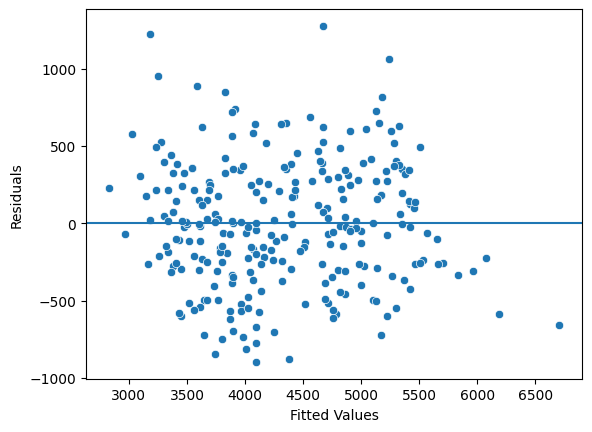

In [25]:
# Import matplotlib
import matplotlib.pyplot as plt
fig = sns.scatterplot(x=fitted_values, y=residuals)

# Add reference line at residuals = 0
fig.axhline(0)

# Set x-axis and y-axis labels
fig.set_xlabel("Fitted Values")
fig.set_ylabel("Residuals")

# Show the plot
plt.show()

**¡Felicidades!** Has completado este laboratorio. Sin embargo, es posible que no notes una marca de verificación verde junto a este elemento en la plataforma de Coursera. Por favor, continúa con tu progreso independientemente de la marca de verificación. Solo haz clic en el icono de "guardar" en la parte superior de este cuaderno para asegurarte de que tu trabajo ha sido registrado.

Ahora entiendes cómo construir un modelo de regresión lineal simple con Python. En adelante, puedes comenzar a usar modelos de regresión lineal simple con tus propios conjuntos de datos.
